In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.vector_ar.var_model import VAR

# ---------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------
data_path = '../VECM/vecm_transformed_data.csv' 
df = pd.read_csv(data_path, index_col=0, parse_dates=True)

# Index 0: ln_ASPI | Index 1: ln_Exchange_Rate | Index 2: Interest_Rate | Index 3: ln_CCPI
variables = ['ln_ASPI', 'ln_Exchange_Rate', 'Interest_Rate', 'ln_CCPI']
data = df[variables]

# # ---------------------------------------------------------
# # 2. Re-build the exact model
# # ---------------------------------------------------------
# print("Re-building VECM from CSV data...")

# # Parameters from text output: 
# # k_ar_diff = 5, coint_rank = 1, deterministic term = 'colo'
# model = VECM(data, deterministic='colo', k_ar_diff=5, coint_rank=1)
# vecm_res = model.fit()

# # Get the VAR representation to run the IRF and VD math
# var_rep = vecm_res.var_rep
# print("Model built successfully!")

# ---------------------------------------------------------
# 2. Fit the Equivalent VAR(6) Model
# ---------------------------------------------------------
print("Fitting equivalent VAR(6) model to generate IRF and VD...")
# A VECM with 5 differenced lags is equivalent to a VAR with 6 levels lags
var_model = VAR(data)
var_res = var_model.fit(6) 
print("Model built successfully!")



Fitting equivalent VAR(6) model to generate IRF and VD...
Model built successfully!


c:\Users\sabit\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



--- Variance Decomposition for ln_ASPI (%) ---
       ln_ASPI  ln_Exchange_Rate  Interest_Rate  ln_CCPI
Day 1   100.00              0.00           0.00     0.00
Day 2    99.77              0.00           0.16     0.07
Day 3    99.58              0.01           0.26     0.15
Day 4    99.27              0.04           0.52     0.17
Day 5    98.94              0.19           0.65     0.21
        ln_ASPI  ln_Exchange_Rate  Interest_Rate  ln_CCPI
Day 26    96.34              1.77           0.35     1.53
Day 27    96.29              1.80           0.34     1.58
Day 28    96.24              1.82           0.33     1.62
Day 29    96.18              1.84           0.32     1.66
Day 30    96.13              1.86           0.31     1.70

✓ Variance Decomposition saved as 'variance_decomposition_aspi.csv'


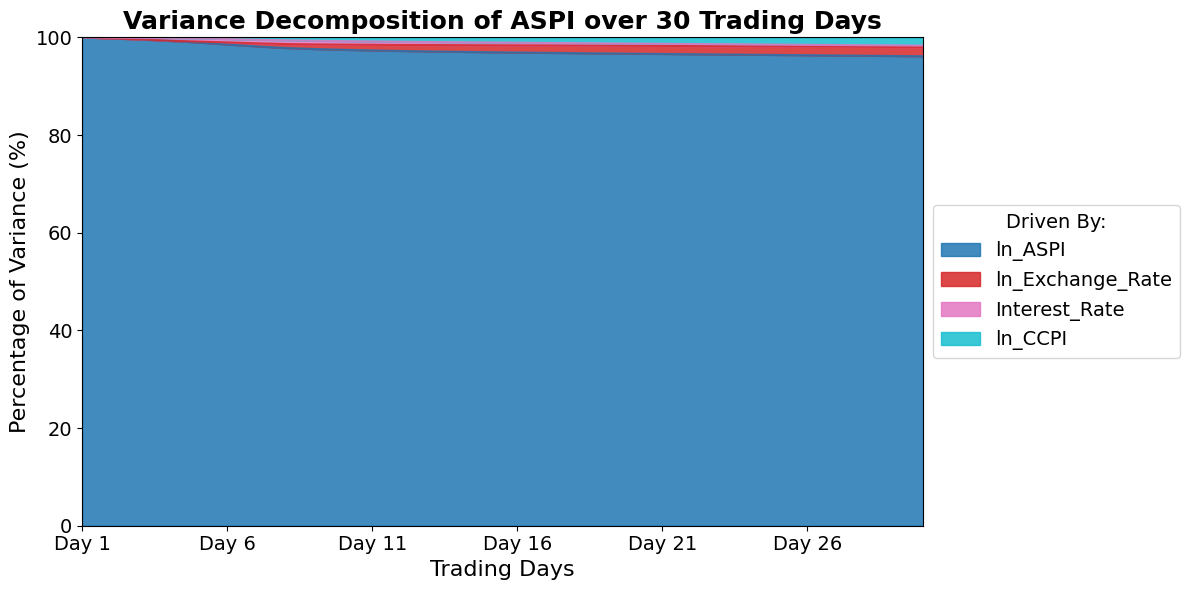

✓ Primary VD Chart saved as 'VD_Stacked_Area_Chart.png'


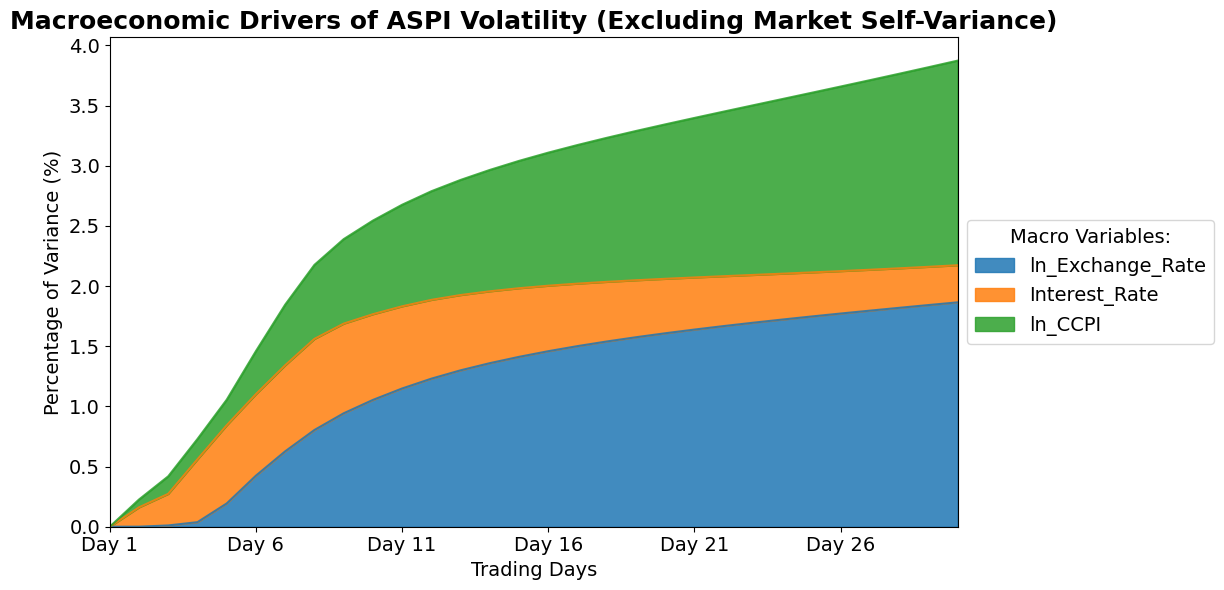

✓ Macro-Only VD Chart saved as 'VD_Macro_Only_Chart.png'


In [24]:
# ---------------------------------------------------------
# 3. Variance Decomposition (VD)
# ---------------------------------------------------------
# Calculate VD for 30 trading days
# vd = var_rep.fevd(30)
vd = var_res.fevd(30)

# ASPI is Index 0 in our variables list
aspi_vd_array = vd.decomp[0, :, :] 

vd_df = pd.DataFrame(
    aspi_vd_array * 100, 
    columns=variables,
    index=[f"Day {i+1}" for i in range(30)]
)

print("\n--- Variance Decomposition for ln_ASPI (%) ---")
print(vd_df.round(2).head()) 
print(vd_df.round(2).tail())
vd_df.to_csv('variance_decomposition_aspi.csv')
print("\n✓ Variance Decomposition saved as 'variance_decomposition_aspi.csv'")

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting using pandas built-in area plot functionality
# 'tab10' provides distinct, professional colors
vd_df.plot(kind='area', stacked=True, ax=ax, alpha=0.85, colormap='tab10', fontsize=14)

# Formatting the Chart for the Paper
ax.set_title('Variance Decomposition of ASPI over 30 Trading Days', fontsize=18, fontweight='bold')
ax.set_ylabel('Percentage of Variance (%)', fontsize=16)
ax.set_xlabel('Trading Days', fontsize=16)

# Force the Y-axis to be exactly 0 to 100
ax.set_ylim(0, 100)
# Remove the white space gaps on the left and right edges
ax.margins(x=0) 

# Move the legend outside the chart so it doesn't cover the data
ax.legend(title="Driven By:",title_fontsize=14, fontsize=14, loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()

# Save the high-resolution image
plt.savefig('VD_Stacked_Area_Chart.png', dpi=300)
plt.show()
print("✓ Primary VD Chart saved as 'VD_Stacked_Area_Chart.png'")

# Create a secondary DataFrame dropping the ASPI column
macro_vd_df = vd_df.drop(columns=['ln_ASPI'])

# Plotting the Macro-Only Area Chart
fig2, ax2 = plt.subplots(figsize=(12, 6))
macro_vd_df.plot(kind='area', stacked=True, ax=ax2, alpha=0.85, fontsize=14)

ax2.set_title('Macroeconomic Drivers of ASPI Volatility (Excluding Market Self-Variance)', fontsize=18, fontweight='bold')
ax2.set_ylabel('Percentage of Variance (%)', fontsize=14)
ax2.set_xlabel('Trading Days', fontsize=14)
ax2.margins(x=0) 
ax2.legend(title="Macro Variables:", title_fontsize=14, fontsize=14, loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.savefig('VD_Macro_Only_Chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Macro-Only VD Chart saved as 'VD_Macro_Only_Chart.png'")


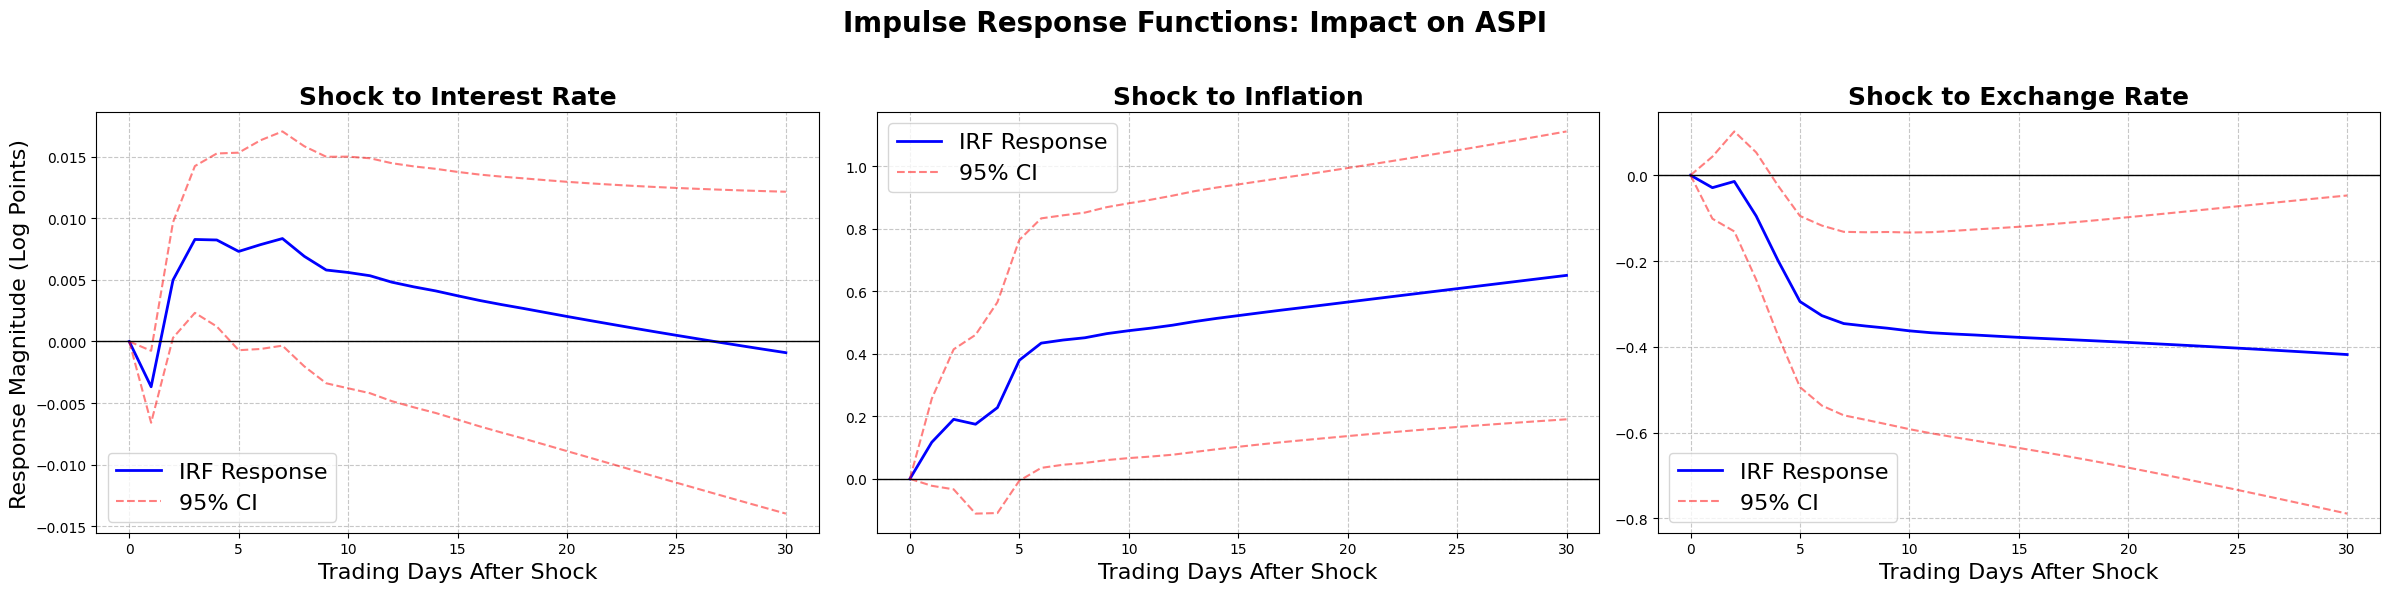

✓ Saved combined IRF chart: IRF_Combined.png


In [ ]:
# ---------------------------------------------------------
# 4. Impulse Response Functions (IRFs) - Combined Strip Chart
# ---------------------------------------------------------
# irf = var_rep.irf(30)
irf = var_res.irf(30)

# We want to see how these three variables shock the ASPI (Index 0)
macro_shocks = {
    'Interest_Rate': 2,       # Index in the variables list
    'Inflation': 3,           # Index in the variables list
    'ln_Exchange_Rate': 1     # Index in the variables list
}

# Create one horizontal strip with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True)

for i, (shock_name, shock_index) in enumerate(macro_shocks.items()):
    ax = axes[i]

    # Extract the specific response and confidence intervals
    # irf.irfs holds [time, response_var, shock_var]
    response = irf.irfs[:, 0, shock_index]
    stderr = irf.stderr()
    lower_bound = response - 1.96 * stderr[:, 0, shock_index]
    upper_bound = response + 1.96 * stderr[:, 0, shock_index]

    # Plotting
    ax.plot(response, color='blue', linewidth=2, label='IRF Response')
    ax.plot(lower_bound, 'r--', alpha=0.5, label='95% CI')
    ax.plot(upper_bound, 'r--', alpha=0.5, label='_nolegend_')
    ax.axhline(0, color='black', linewidth=1)

    # Formatting
    clean_name = shock_name.replace('ln_', '').replace('_', ' ')
    ax.set_title(f'Shock to {clean_name}', fontsize=18, fontweight='bold')
    ax.set_xlabel('Trading Days After Shock', fontsize=16)
    if i == 0:
        ax.set_ylabel('Response Magnitude (Log Points)', fontsize=16)

    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=16)

fig.suptitle('Impulse Response Functions: Impact on ASPI', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save a single combined chart for the paper
combined_filename = 'IRF_Combined.png'
plt.savefig(combined_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved combined IRF chart: {combined_filename}")